In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy as sp
import os
import glob
import netCDF4 # 
from netCDF4 import Dataset, num2date
import seaborn
import datetime as datetime
import h5py 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime as datetime




In [16]:
ds= xr.open_dataset('/Users/Daniela/Documents/TRIATLAS/tropical_atlantic/SST_MHW_TropicalAtlantic.nc') #abrir xarray um arquivo netcdf 


In [17]:
ds


<xarray.Dataset>
Dimensions:       (lat: 68, lon: 160, time: 13879)
Coordinates:
  * lat           (lat) float32 -6.875 -6.625 -6.375 ... 9.375 9.625 9.875
  * lon           (lon) float32 320.125 320.375 320.625 ... 359.625 359.875
  * time          (time) int32 723546 723547 723548 ... 737422 737423 737424
Data variables:
    sst           (time, lat, lon) float32 ...
    sst_anom      (time, lat, lon) float64 ...
    mhw_category  (time, lat, lon) int32 ...
    seas          (time, lat, lon) float64 ...
    thresh        (time, lat, lon) float64 ...
Attributes:
    description:  SST and MHW (Benguela and Agulhas).

In [18]:
temp = ds.variables['sst'][:]
time = ds.variables['time'][:]
lat = ds.variables['lat'][0:10]
lon = ds.variables['lon'][260:349]


In [19]:
lon

<xarray.IndexVariable 'lon' (lon: 0)>
array([], dtype=float32)

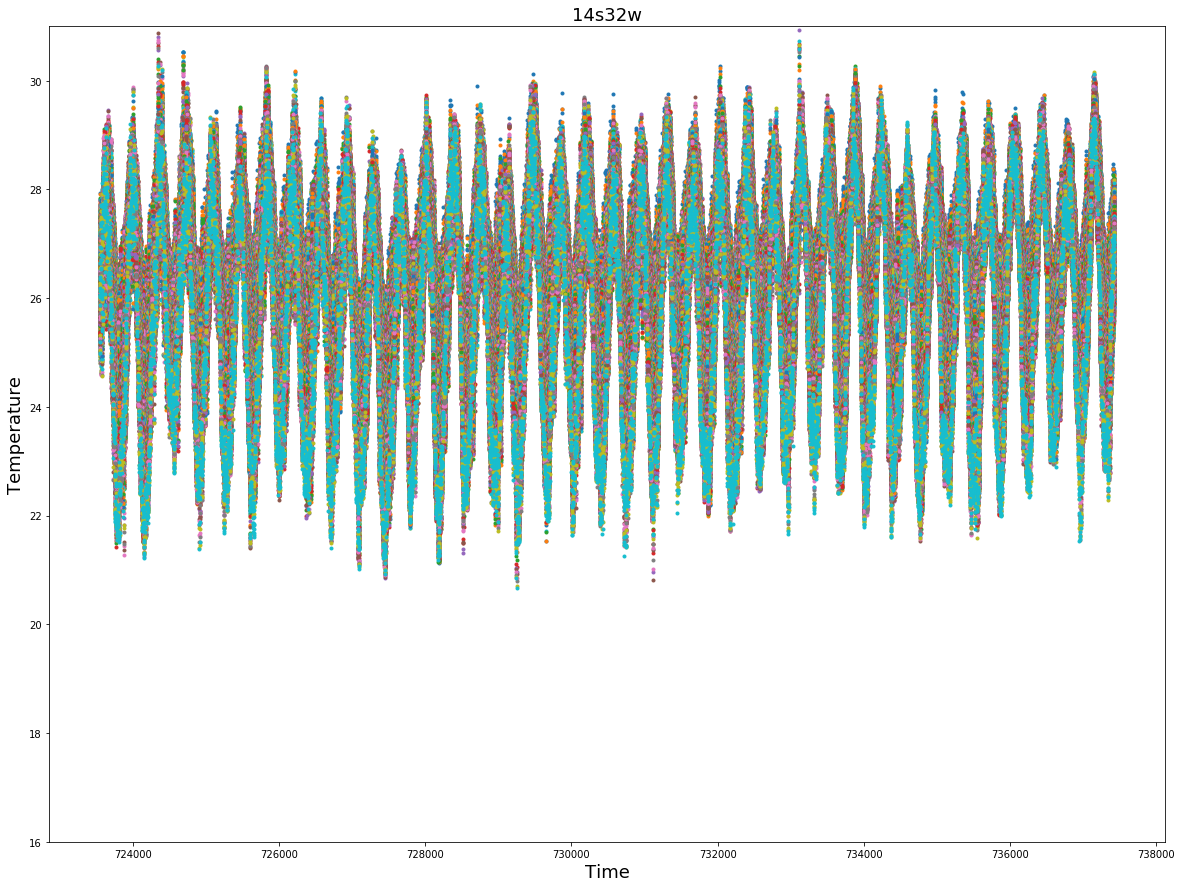

In [20]:
plt.rcParams["figure.figsize"] = (20,15)

plt.plot(time,temp[:,0],'.')
x1,x2,y1,y2 = plt.axis()
plt.axis((x1,x2,16,31))
plt.title('14s32w', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.ylabel('Temperature', fontsize=18)
plt.show()

In [16]:
os.chdir('/Users/Daniela/Documents/TRIATLAS/SST/')

In [17]:
files=glob.glob(os.path.basename('/*.nc'))
files.sort() # coloca em ordem ascendente


In [18]:
print(files)

['SST_MHW_NorthAtlantic.nc', 'sst.day.mean.1981.nc', 'sst.day.mean.1981.v2.nc', 'sst.day.mean.1982.nc', 'sst.day.mean.1982.v2.nc', 'sst.day.mean.1983.nc', 'sst.day.mean.1983.v2.nc', 'sst.day.mean.1984.nc', 'sst.day.mean.1984.v2.nc', 'sst.day.mean.1985.nc', 'sst.day.mean.1985.v2.nc', 'sst.day.mean.1986.nc', 'sst.day.mean.1986.v2.nc', 'sst.day.mean.1987.nc', 'sst.day.mean.1987.v2.nc', 'sst.day.mean.1988.nc', 'sst.day.mean.1988.v2.nc', 'sst.day.mean.1989.nc', 'sst.day.mean.1989.v2.nc', 'sst.day.mean.1990.nc', 'sst.day.mean.1999.nc', 'sst.day.mean.2020.nc']


In [19]:
file=files[0] # files é a lista dos arquivos .nc


In [20]:
file

'SST_MHW_NorthAtlantic.nc'

In [21]:
nc = netCDF4.Dataset(file, mode='r') # open nc file
print(nc.variables.keys())

dict_keys(['sst', 'sst_anom', 'mhw_category', 'seas', 'thresh', 'lat', 'lon', 'time'])


In [22]:
print(nc.variables.values()) # metadata variáveis

dict_values([<class 'netCDF4._netCDF4.Variable'>
float32 sst(time, lat, lon)
    _FillValue: nan
unlimited dimensions: 
current shape = (2922, 160, 360)
filling on, <class 'netCDF4._netCDF4.Variable'>
float64 sst_anom(time, lat, lon)
    _FillValue: nan
unlimited dimensions: 
current shape = (2922, 160, 360)
filling on, <class 'netCDF4._netCDF4.Variable'>
int32 mhw_category(time, lat, lon)
unlimited dimensions: 
current shape = (2922, 160, 360)
filling on, default _FillValue of -2147483647 used, <class 'netCDF4._netCDF4.Variable'>
float64 seas(time, lat, lon)
    _FillValue: nan
unlimited dimensions: 
current shape = (2922, 160, 360)
filling on, <class 'netCDF4._netCDF4.Variable'>
float64 thresh(time, lat, lon)
    _FillValue: nan
unlimited dimensions: 
current shape = (2922, 160, 360)
filling on, <class 'netCDF4._netCDF4.Variable'>
float32 lat(lat)
    _FillValue: nan
unlimited dimensions: 
current shape = (160,)
filling on, <class 'netCDF4._netCDF4.Variable'>
float32 lon(lon)
    _Fi

<ipython-input-22-ba8776a7c241>:1: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  print(nc.variables.values()) # metadata variáveis


In [24]:
# converter data

time = nc.variables['time']
#date = num2date(time[:], time.units)

(360,)
(160,)


(2922, 160, 360)

<Figure size 432x288 with 0 Axes>

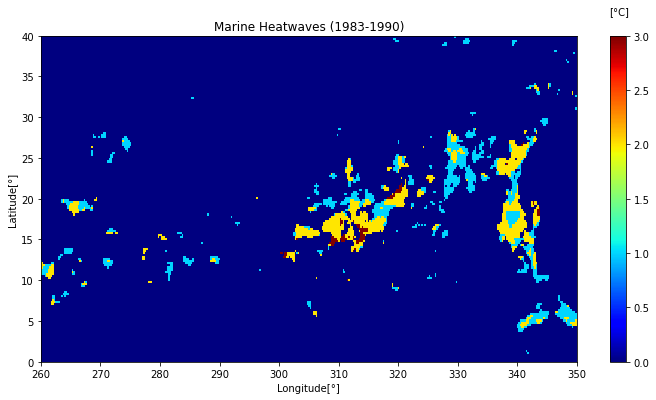

In [35]:
# Carregar Lat e Lon

lat0 = nc.variables['lat'][:]
lon0 = nc.variables['lon'][:]

# Ver dimensões

print(lon0.shape)
print(lat0.shape)

# Carregar variável principal

mhw_category=nc.variables['mhw_category'][:]

mhw_category.shape

# Plotar

plt.figure()
plt.figure(figsize=(12,6))
plt.pcolormesh(lon0,lat0,mhw_category[0,:,:],cmap='jet', shading='auto')
cmap = plt.cm.gist_rainbow
cbar = plt.colorbar()
cbar.set_label('[°C]',rotation=0,labelpad=-30,y=1.09)
plt.xlabel('Longitude[°]')
plt.ylabel('Latitude[°]')
plt.title('Marine Heatwaves (1983-1990)')

# No caso de Greenwich não ser o centro:

mask_lon1=lon0<=180
mask_lon2=lon0>180


lon1=lon0[mask_lon1]
lon2=lon0[mask_lon2]


lon_part1=np.flip(lon1)
lon_part1=lon_part1[lon_part1>0]*(-1)

# Novo vetor longitude

lon3=np.ma.append(lon_part1,lon1)

aaa1=mhw_category[:,:,mask_lon1]

aaa2=mhw_category[:,:,mask_lon2]

# Nova variável principal ajustada no mapa

aaa3=np.ma.concatenate([aaa2,aaa1],2)

aaa3.shape